# GHR Quickstart

**Graph Hierarchical Recurrence** is a GNN that maintains two coupled hidden states: one on the original graph (`h_L`, fine level) and one on a coarsened abstraction (`h_H`, coarse level). At each recurrent step the coarse level provides long-range context to the fine level, and the fine level summarises back up. You call the model `T` times, threading the returned state back in — the receptive field grows with `T`, not with depth.

In the next ~2 minutes you will:
1. Build a small random geometric graph
2. Visualise the graph
3. Instantiate GHR and run a forward pass
4. Visualise the two-level hierarchy that GHR operates on
5. See how the predicted output evolves across reasoning steps

In [43]:
import sys, os
sys.path.insert(0, os.path.join('..', 'experiments', 'rgg'))
sys.path.insert(0, '..')  # repo root — ghr_model.py lives here

import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import numpy as np

torch.manual_seed(42)
import random; random.seed(42)
np.random.seed(42)

print('torch:', torch.__version__)

torch: 2.9.0


## Step 1 — Build a small graph

We generate a **random geometric graph**: nodes are placed uniformly at random in the unit square, edges connect pairs within a fixed radius. Edge weights are travel distances (Euclidean). We then pick a random source node and ask: *what is the hop-distance from the source to every other node?* — the classic SSSP task that GHR was benchmarked on.

The graph is also **coarsened once** using the Graclus algorithm (the same step that happens at dataset preprocessing time). This is what produces the `cluster`, `coarse_edge_index`, and `coarse_edge_attr` fields that GHR needs.

In [44]:
from OOR_dataset import generate_rgg_sample

data = generate_rgg_sample(
    num_nodes=40,
    radius=0.28,          # connection radius in [0,1]^2
    graclus_rounds=2,     # rounds of Graclus coarsening
    max_distance=12,
    self_loops=True,
)

n_fine   = data.x.size(0)
n_coarse = data.num_coarse_nodes
source   = int(data.x.squeeze().argmax())   # x encodes the source node as 1.0

print(f'Fine graph  : {n_fine} nodes, {data.edge_index.size(1)} edges (incl. self-loops)')
print(f'Coarse graph: {n_coarse} nodes, {data.coarse_edge_index.size(1)} edges')
print(f'Source node : {source}')
print(f'y (hop dist): min={data.y[data.mask].min():.0f}, max={data.y[data.mask].max():.0f}')

Fine graph  : 40 nodes, 312 edges (incl. self-loops)
Coarse graph: 12 nodes, 60 edges
Source node : 7
y (hop dist): min=0, max=5


## Step 2 — Visualise the input graph

Nodes are coloured by their hop-distance from the source (blue = near, yellow = far). The source node is marked with a star.

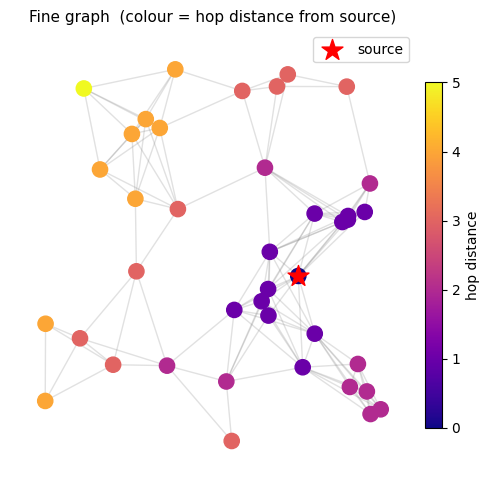

In [45]:
pos_np = data.pos.numpy()           # (N, 2) positions in [0,1]^2
y_np   = data.y.numpy()             # hop distances (−1 for unreachable)
reachable = data.mask.numpy()

# Build NetworkX graph (excluding self-loops for drawing)
ei = data.edge_index.numpy()
edges = [(ei[0, i], ei[1, i]) for i in range(ei.shape[1]) if ei[0, i] != ei[1, i]]
G = nx.Graph()
G.add_nodes_from(range(n_fine))
G.add_edges_from(edges)
nxpos = {i: pos_np[i] for i in range(n_fine)}

colors = ['#cccccc'] * n_fine
cmap = cm.plasma
dmax = y_np[reachable].max()
for i in range(n_fine):
    if reachable[i]:
        colors[i] = cmap(y_np[i] / dmax)

fig, ax = plt.subplots(figsize=(5, 5))
nx.draw_networkx_edges(G, nxpos, alpha=0.25, edge_color='#888888', ax=ax)
nx.draw_networkx_nodes(G, nxpos, node_color=colors, node_size=120, ax=ax)
ax.scatter(*pos_np[source], s=250, marker='*', c='red', zorder=5, label='source')
ax.set_title('Fine graph  (colour = hop distance from source)', fontsize=11)
ax.axis('off'); ax.legend(loc='upper right')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, dmax))
sm.set_array([])
plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.02, label='hop distance')
plt.tight_layout()
plt.savefig('fine_graph.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 3 — Instantiate GHR

The two key architectural hyperparameters:
- **`l_steps`**: how many fine-level GINE passes per coarse step (inner loop)
- **`h_steps`**: how many coarse-level steps per forward call (outer loop)
In paper runs `l_steps=6, h_steps=3` is typical for SSSP.

In [46]:
from ghr_model import GHRModel

model = GHRModel(
    input_dim=1,           # data.x is 1-D (source indicator)
    output_dim=1,
    hidden_dim=32,
    l_steps=6,
    h_steps=3,
    use_swiglu=False,
    node_level_task=True,
    edge_dim_coarse=2,     # OOR_dataset coarse edges: [min_w, mean_w]
)
model.eval()

ckpt_path = "rgg_checkpoint.ckpt"
state_dict = torch.load(ckpt_path, map_location='cpu')['state_dict']
if next(iter(state_dict)).startswith('model.'):
    state_dict = {k.replace('model.', '', 1): v for k, v in state_dict.items()}

#model.load_state_dict(state_dict)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')
print(model)

Parameters: 7,747
GHRModel(
  (dropout): Dropout(p=0.0, inplace=False)
  (input_proj): Linear(in_features=1, out_features=32, bias=True)
  (edge_encoder_fine): Linear(in_features=1, out_features=32, bias=True)
  (edge_encoder_coarse): Linear(in_features=2, out_features=32, bias=True)
  (norm_coarse): RMSNorm()
  (norm_fine): RMSNorm()
  (gnn_coarse): GINEConv(nn=Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): SiLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
  ))
  (gnn_fine): GINEConv(nn=Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): SiLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
  ))
  (context_proj): Linear(in_features=32, out_features=32, bias=False)
  (regressor): Linear(in_features=32, out_features=1, bias=True)
)


## Step 4 — Forward pass

We call the model `T = 4` times, threading the returned `(h_L, h_H)` state back in at each step. The receptive field grows with each step — early steps see only local neighbourhood structure, later steps integrate global context via the coarse level.

In [38]:
T = 5  # global recurrence steps

predictions = []
state = None
with torch.no_grad():
    for t in range(T):
        pred, state = model(data, state=state)
        predictions.append(pred.numpy().copy())

final_pred = predictions[-1]
target = data.y.numpy()
mask = data.mask.numpy()

mae = float(np.abs(final_pred[mask] - target[mask]).mean())
print(f'Output shape : {pred.shape}')
print(f'state h_L    : {state[0].shape}  (one vector per fine node)')
print(f'state h_H    : {state[1].shape}  (one vector per coarse node)')
print(f'MAE after T={T} steps (untrained): {mae:.3f}  — meaningful only after training')

Output shape : torch.Size([40])
state h_L    : torch.Size([40, 32])  (one vector per fine node)
state h_H    : torch.Size([12, 32])  (one vector per coarse node)
MAE after T=5 steps (untrained): 280.914  — meaningful only after training


## Step 5 — Watch predictions evolve across reasoning steps

Even without training, you can see the prediction pattern stabilise across global recurrence steps. After training the final-step prediction closely tracks the true hop distances.

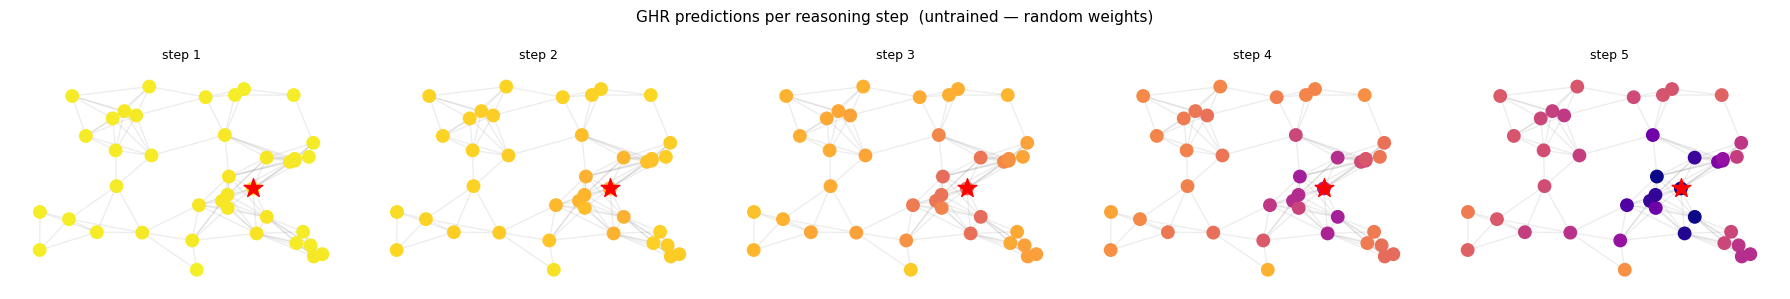

In [41]:
fig, axes = plt.subplots(1, T , figsize=(3 * (T + 1), 3))

all_vals = np.concatenate([p[mask] for p in predictions] + [target[mask]])
vmin, vmax = all_vals.min(), all_vals.max()

def draw(ax, values, title):
    node_colors = []
    for i in range(n_fine):
        if mask[i]:
            node_colors.append(cmap((values[i] - vmin) / (vmax - vmin + 1e-8)))
        else:
            node_colors.append('#cccccc')
    nx.draw_networkx_edges(G, nxpos, alpha=0.15, edge_color='#888888', ax=ax)
    nx.draw_networkx_nodes(G, nxpos, node_color=node_colors, node_size=80, ax=ax)
    ax.scatter(*pos_np[source], s=200, marker='*', c='red', zorder=5)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

for t, pred in enumerate(predictions):
    draw(axes[t], pred, f'step {t+1}')

fig.suptitle('GHR predictions per reasoning step  (untrained — random weights)', fontsize=11)
plt.tight_layout()
plt.savefig('reasoning_steps.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 6 — Visualise the two-level hierarchy

The key structural innovation in GHR: every fine node belongs to exactly one coarse cluster (shown by colour). The coarse graph connects clusters whose fine-level nodes share at least one edge. GHR passes messages on **both** graphs simultaneously, then uses the coarse state to inject global context into each fine-level step.

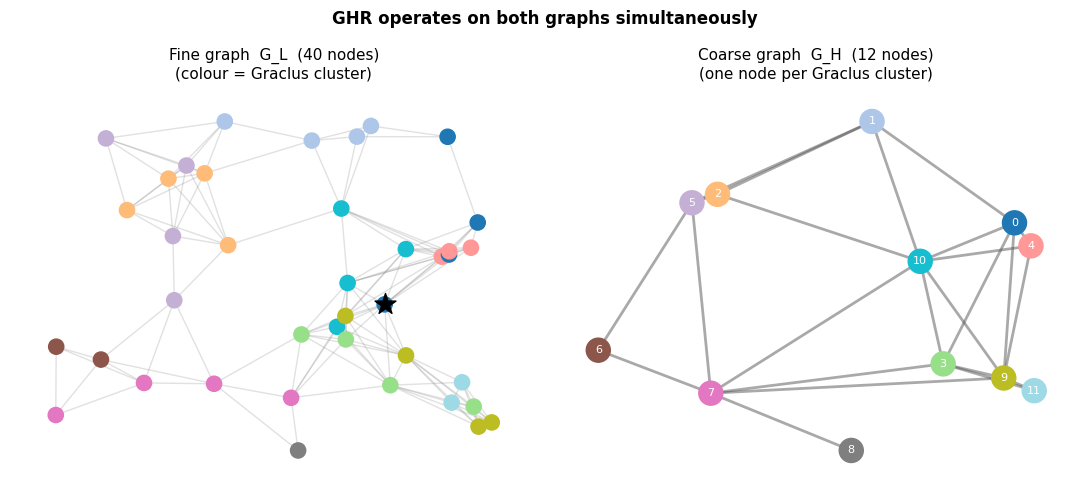

Coarsening ratio: 40 → 12 nodes  (70% reduction)


In [42]:
cluster = data.cluster.numpy()       # fine→coarse assignment
coarse_pos = data.coarse_pos.numpy() # (n_coarse, 2)

cluster_colors = plt.cm.tab20(np.linspace(0, 1, n_coarse))
fine_colors_by_cluster = [cluster_colors[cluster[i]] for i in range(n_fine)]

# Coarse graph (excluding self-loops)
cei = data.coarse_edge_index.numpy()
coarse_edges = [(cei[0, i], cei[1, i]) for i in range(cei.shape[1]) if cei[0, i] != cei[1, i]]
G_coarse = nx.Graph()
G_coarse.add_nodes_from(range(n_coarse))
G_coarse.add_edges_from(coarse_edges)
coarse_nxpos = {i: coarse_pos[i] for i in range(n_coarse)}
coarse_node_colors = [cluster_colors[i] for i in range(n_coarse)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Fine graph — nodes coloured by cluster membership
nx.draw_networkx_edges(G, nxpos, alpha=0.25, edge_color='#888888', ax=ax1)
nx.draw_networkx_nodes(G, nxpos, node_color=fine_colors_by_cluster, node_size=120, ax=ax1)
ax1.scatter(*pos_np[source], s=250, marker='*', c='black', zorder=5)
ax1.set_title(f'Fine graph  G_L  ({n_fine} nodes)\n(colour = Graclus cluster)', fontsize=11)
ax1.axis('off')

# Coarse graph — one node per cluster, positioned at cluster centroid
nx.draw_networkx_edges(G_coarse, coarse_nxpos, alpha=0.5, edge_color='#555555', width=2, ax=ax2)
nx.draw_networkx_nodes(G_coarse, coarse_nxpos, node_color=coarse_node_colors, node_size=300, ax=ax2)
nx.draw_networkx_labels(G_coarse, coarse_nxpos,
                        labels={i: str(i) for i in range(n_coarse)},
                        font_size=8, font_color='white', ax=ax2)
ax2.set_title(f'Coarse graph  G_H  ({n_coarse} nodes)\n(one node per Graclus cluster)', fontsize=11)
ax2.axis('off')

plt.suptitle('GHR operates on both graphs simultaneously', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('hierarchy.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Coarsening ratio: {n_fine} → {n_coarse} nodes  '
      f'({100*(1 - n_coarse/n_fine):.0f}% reduction)')

## What's next?

**Train on real benchmarks** — the training scripts are in:
- `benchmarks/echo/scripts/` — ECHO-Synth (SSSP, diameter, eccentricity) and ECHO-Chem (energy, charge)
- `experiments/lrgb/` — LRGB Peptides-struct (molecular property prediction)
- `experiments/rgg/` — ablation study against GIN, GCN, GAT, GPS baselines
- `benchmarks/lrim/example-setup/` — LRIM (Ising model long-range benchmark)

**Run all sanity checks** with `bash smoke_test.sh` from the repo root (8 tests, no GPU required).

**Read the paper** for the full architecture description, theoretical motivation, and numerical results.